In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

In [2]:
df = pd.read_csv("shiller.csv")

print(df.head())
print(df.info())
print(df.describe())

         date    sp500  consumer_price_index  long_interest_rate
0  2010-11-01  1198.89                218.80                2.76
1  2010-12-01  1241.53                219.18                3.29
2  2011-01-01  1282.62                220.22                3.39
3  2011-02-01  1321.12                221.31                3.58
4  2011-03-01  1304.49                223.47                3.41
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  70 non-null     str    
 1   sp500                 70 non-null     float64
 2   consumer_price_index  70 non-null     float64
 3   long_interest_rate    70 non-null     float64
dtypes: float64(3), str(1)
memory usage: 3.0 KB
None
             sp500  consumer_price_index  long_interest_rate
count    70.000000             70.000000           70.000000
mean   1689.146714            232.6670

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [4]:
X = df.select_dtypes(include=np.number)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

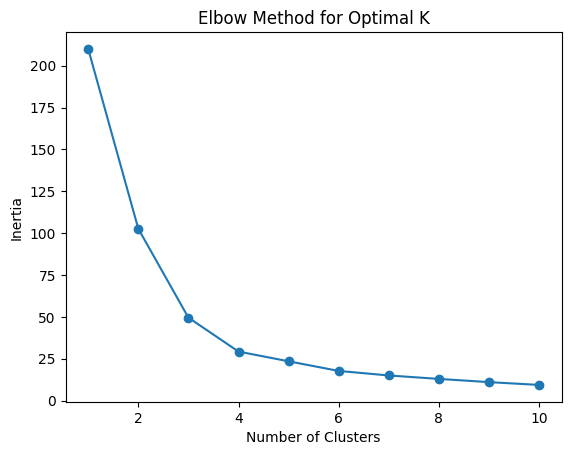

In [5]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [6]:
k = 3  # change based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,date,sp500,consumer_price_index,long_interest_rate,cluster
0,2010-11-01,1198.89,218.80,2.76,2
1,2010-12-01,1241.53,219.18,3.29,2
2,2011-01-01,1282.62,220.22,3.39,2
3,2011-02-01,1321.12,221.31,3.58,2
4,2011-03-01,1304.49,223.47,3.41,2


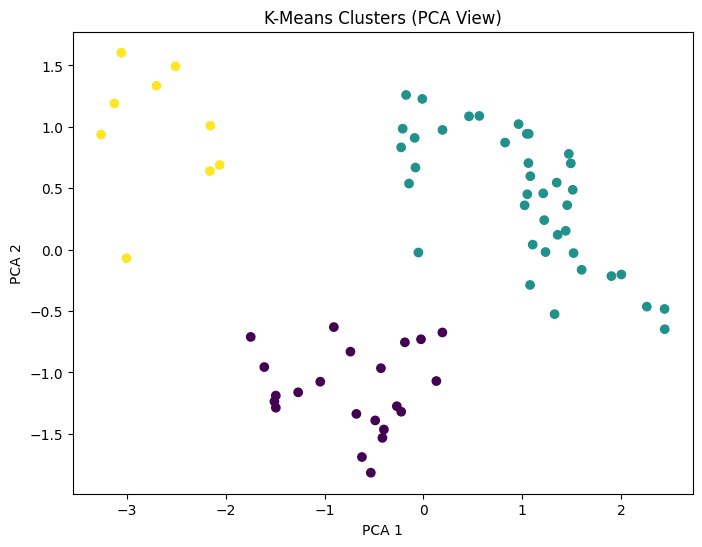

In [7]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df["pca1"] = components[:, 0]
df["pca2"] = components[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], cmap="viridis")
plt.title("K-Means Clusters (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [9]:
text_cols = df.select_dtypes(include="string").columns
print("Text columns found:", text_cols)

Text columns found: Index(['date'], dtype='str')


In [15]:
numeric_features = df.select_dtypes(include=["int64", "float64"])

In [16]:
df.groupby("cluster")[num_cols].mean()

,sp500,consumer_price_index,long_interest_rate
cluster,,,
0,1379.317727,229.434545,1.890455
1,1955.495641,236.760000,2.278974
2,1292.327778,222.832222,3.228889


In [17]:
df.to_csv("shiller_clustered.csv", index=False)